In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("AAMC.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-12-13,15.0,15.0,15.0,15.0,15.0,100
1,2012-12-14,19.0,30.0,19.0,30.0,30.0,144600
2,2012-12-17,31.5,65.0,31.5,65.0,65.0,68600
3,2012-12-18,65.0,89.0,65.0,80.0,80.0,43600
4,2012-12-19,80.0,84.0,78.0,84.0,84.0,24000


In [4]:
data = df['Close'].to_numpy().reshape(-1, 1)

In [7]:
data.dtype

dtype('float64')

In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [20]:
data_scaled

array([[0.00589884],
       [0.01852117],
       [0.04797328],
       ...,
       [0.0036184 ],
       [0.00488905],
       [0.00493112]], shape=(1837, 1))

In [23]:
def create_seq(data, time_step = 60):
    X,y = [],[]
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0])
        y.append(data[i, 0])
    
    return np.array(X), np.array(y)

In [24]:
X, y = create_seq(data_scaled, 60)

In [26]:
X.shape

(1777, 60)

In [27]:
y.shape

(1777,)

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(40, return_sequences=True, input_shape=(X.shape[1], 1)),
    LSTM(40),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")

In [36]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [50]:
history = model.fit(X_train, y_train, epochs=25)

Epoch 1/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.4381e-04
Epoch 2/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 7.3004e-04
Epoch 3/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.7569e-04
Epoch 4/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2085e-04
Epoch 5/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.3231e-04
Epoch 6/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 8.4116e-04
Epoch 7/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.2257e-04
Epoch 8/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.4664e-04
Epoch 9/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.4060e-04
Epoch 10/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.1994e-04
Epoch 11/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.3082e-04
Epoch 12/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.3220e-04
Epoch 13/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.3072e-04
Epoch 14/25
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.6561e-04
Epoch 15/25
45/

In [51]:
y_pred = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [52]:
y_pred = scaler.inverse_transform(y_pred)

In [53]:
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

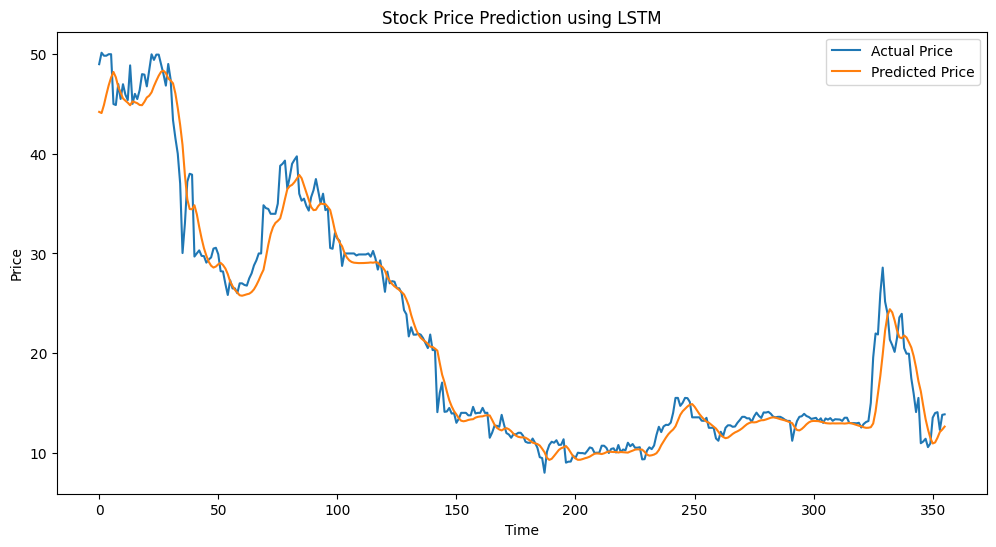

In [54]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(y_pred, label='Predicted Price')

plt.title("Stock Price Prediction using LSTM")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()